# Evaluation of Root Heights

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib import gridspec

import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations

from evaluation_helpers import *

In [2]:
tree_metrics_combined = load_node_errors("../results/run1/evaluation")
root_height_df_wide = tree_metrics_combined[tree_metrics_combined['node_id'] == "internal_0"]
root_height_df_wide.to_csv("../results/run1/evaluation/root_height_info.csv", sep= "\t", index = False)

/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3708: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(tsv, sep="\t"))
/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3708: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(tsv, sep="\t"))
/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3708: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(tsv, sep="\t"))
/Users/mariebecker/Documents/Uni/ETH/RotationStadler/BESP_paper-analyses/workflows/evaluation_helpers.py:3708: DtypeWarning: Columns (50,94) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.r

In [2]:
root_height_df_wide = pd.read_csv("../results/run1/evaluation/root_height_info.csv", sep= "\t")
root_height_df_wide

,tree_index,node_idx,node_id,internal,height_sim,bl_sim,constcoal_pop_diff_median,constcoal_pop_diff_hpd_lower,constcoal_pop_diff_hpd_upper,constcoal_pop_rel_error_median,...,skyline_height_est_hpd_lower,skyline_height_est_hpd_upper,skyline_bl_est_median,skyline_bl_est_hpd_lower,skyline_bl_est_hpd_upper,skyline_height_inside_ci,skyline_bl_inside_ci,sampling,population_model,mutation_signal
0,0,0,internal_0,True,2995.021345,0.0,-127.088000,-236.003536,-6.320547,-0.127088,...,4080.487948,4440.618703,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
1,1,0,internal_0,True,1797.360469,0.0,-154.919397,-258.509556,-44.732510,-0.154919,...,1922.481100,2087.252494,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
2,2,0,internal_0,True,3492.044982,0.0,-222.825124,-322.426036,-109.869521,-0.222825,...,5142.319345,5588.547079,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
3,3,0,internal_0,True,1312.193877,0.0,-36.616512,-148.634362,103.990956,-0.036617,...,1375.176615,1538.215136,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
4,4,0,internal_0,True,1743.065750,0.0,-189.882196,-281.729422,-63.797783,-0.189882,...,2030.322342,2236.236307,NaN,NaN,NaN,False,NaN,independenthomochronous,bottleneck,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,95,0,internal_0,True,2100.358660,0.0,40.931492,-83.267563,166.460761,0.040931,...,2183.172762,2461.296638,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med
2125,96,0,internal_0,True,2904.746105,0.0,104.831089,-36.410755,253.747703,0.104831,...,3219.055021,3527.348675,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med
2126,97,0,internal_0,True,4322.027642,0.0,88.866461,-49.887069,220.425725,0.088866,...,5426.885504,5987.801666,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med
2127,98,0,internal_0,True,10935.968474,0.0,280.935944,135.350787,472.927482,0.280936,...,19661.427908,21335.345669,NaN,NaN,NaN,False,NaN,linearconstant,uniform,med


## CI overlap

1.  How much do the constcoal and skyline posterior distributions of root height overlap with each other, per condition.
    - Evaluating the overlap (by assuming a normal distribution of the posterior, since I only have the 95% HPD borders and not the full posterior) shows that the higher the mutation signal, the higher is the overlap between the CIs
    - low mutation signal exponentials have quite low overlap between the confidence intervals

2. How oftern do skyline and constcoal cases get confidence intervals that fit the true root height?
    - bottleneck and uniform tend to be overconfident, especially for high mutation signal were root is very far in the past, heterochronous sampling performs better than homochronous
    - for expgrowth we see that the skyline is a lot better to capture the true uncertainty (especially for low mut. sig.)

In [5]:
display(evaluate_ci_overlap(root_height_df_wide, sampling="linearconstant"))
evaluate_ci_overlap(root_height_df_wide, sampling="independenthomochronous")

population_model  mutation_signal
uniform           high               0.977183
                  med                0.976694
                  low                0.961220
expgrowthslow     high               0.889542
                  med                0.829447
                  low                0.635457
expgrowthfast     high               0.811173
                  med                0.730337
                  low                0.468880
bottleneck        high               0.954558
                  med                0.953488
                  low                0.932448
Name: overlap, dtype: float64

population_model  mutation_signal
uniform           high               0.980634
                  med                0.979898
                  low                0.960946
expgrowthslow     high               0.891822
                  med                0.845931
                  low                0.673121
expgrowthfast     high               0.826068
                  med                0.741434
                  low                0.485431
bottleneck        high               0.979177
                  med                0.976570
                  low                0.975858
Name: overlap, dtype: float64

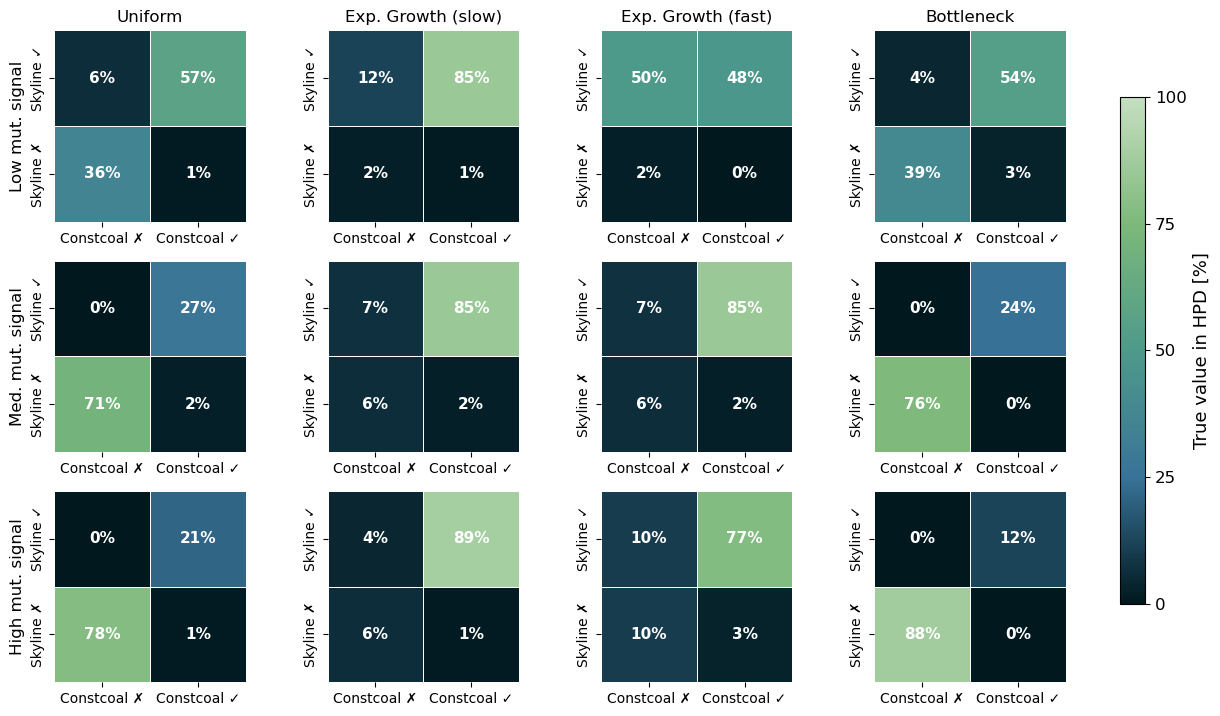

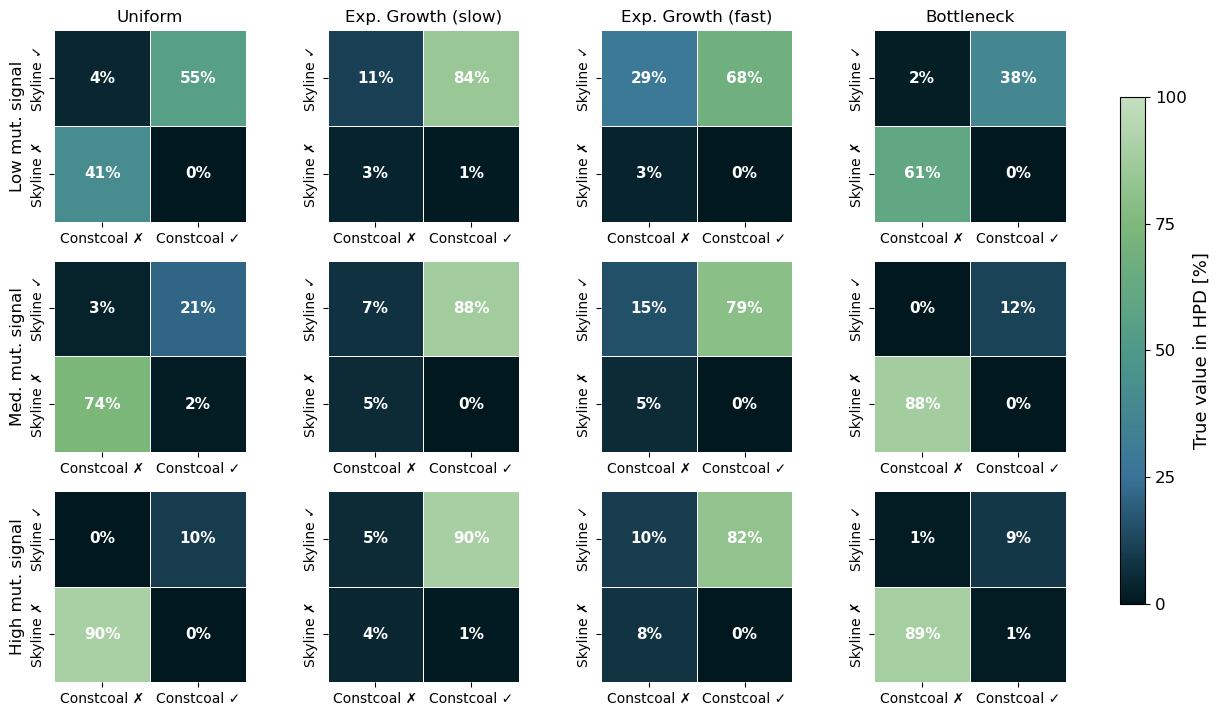

In [3]:
plot_ci_coverage_heatmap(root_height_df_wide, sampling = 'linearconstant', title = "", save_path= "../figures/root_height/hpd_coverage_heatmap_linearconstant.pdf", cbar_label = "True value in HPD [%]")
plot_ci_coverage_heatmap(root_height_df_wide, sampling = 'independenthomochronous', title = "", save_path= "../figures/root_height/hpd_coverage_heatmap_independenthomochronous.pdf", cbar_label = "True value in HPD [%]")

In [7]:
print("Percentage of root height estimates inside 95% HPD by condition and model:")
display(root_height_df_wide.groupby(['population_model', 'mutation_signal', 'sampling']).apply(                                                                                                               
    lambda g: pd.Series({
        "constcoal": g["constcoal_height_inside_ci"].mean(),
        "skyline":   g["skyline_height_inside_ci"].mean(),
    }), include_groups=False
).reset_index())

Percentage of root height estimates inside 95% HPD by condition and model:


,population_model,mutation_signal,sampling,constcoal,skyline
0,bottleneck,high,independenthomochronous,0.100000,0.100000
1,bottleneck,high,linearconstant,0.123711,0.123711
2,bottleneck,low,independenthomochronous,0.375000,0.392857
3,bottleneck,low,linearconstant,0.563380,0.577465
4,bottleneck,med,independenthomochronous,0.118421,0.118421
5,bottleneck,med,linearconstant,0.244681,0.244681
6,expgrowthfast,high,independenthomochronous,0.824176,0.923077
7,expgrowthfast,high,linearconstant,0.800000,0.870000
8,expgrowthfast,low,independenthomochronous,0.681319,0.967033
9,expgrowthfast,low,linearconstant,0.479592,0.979592


## Scatter plot showing error in root height depending on cumulative error in population size

Observations:
- uniform and bottleneck are overconfident, especially for high mut. signal
- for exponentialgrowth, constant coalescent has higher error in rate and also higher error in root height
- we see this effect both for relative and absolute errors which shows that for skyline errors not just cancel each other out
- both heterochronous and homochronous sampling show the same trend but heterochronous sampling is a little bit more clear

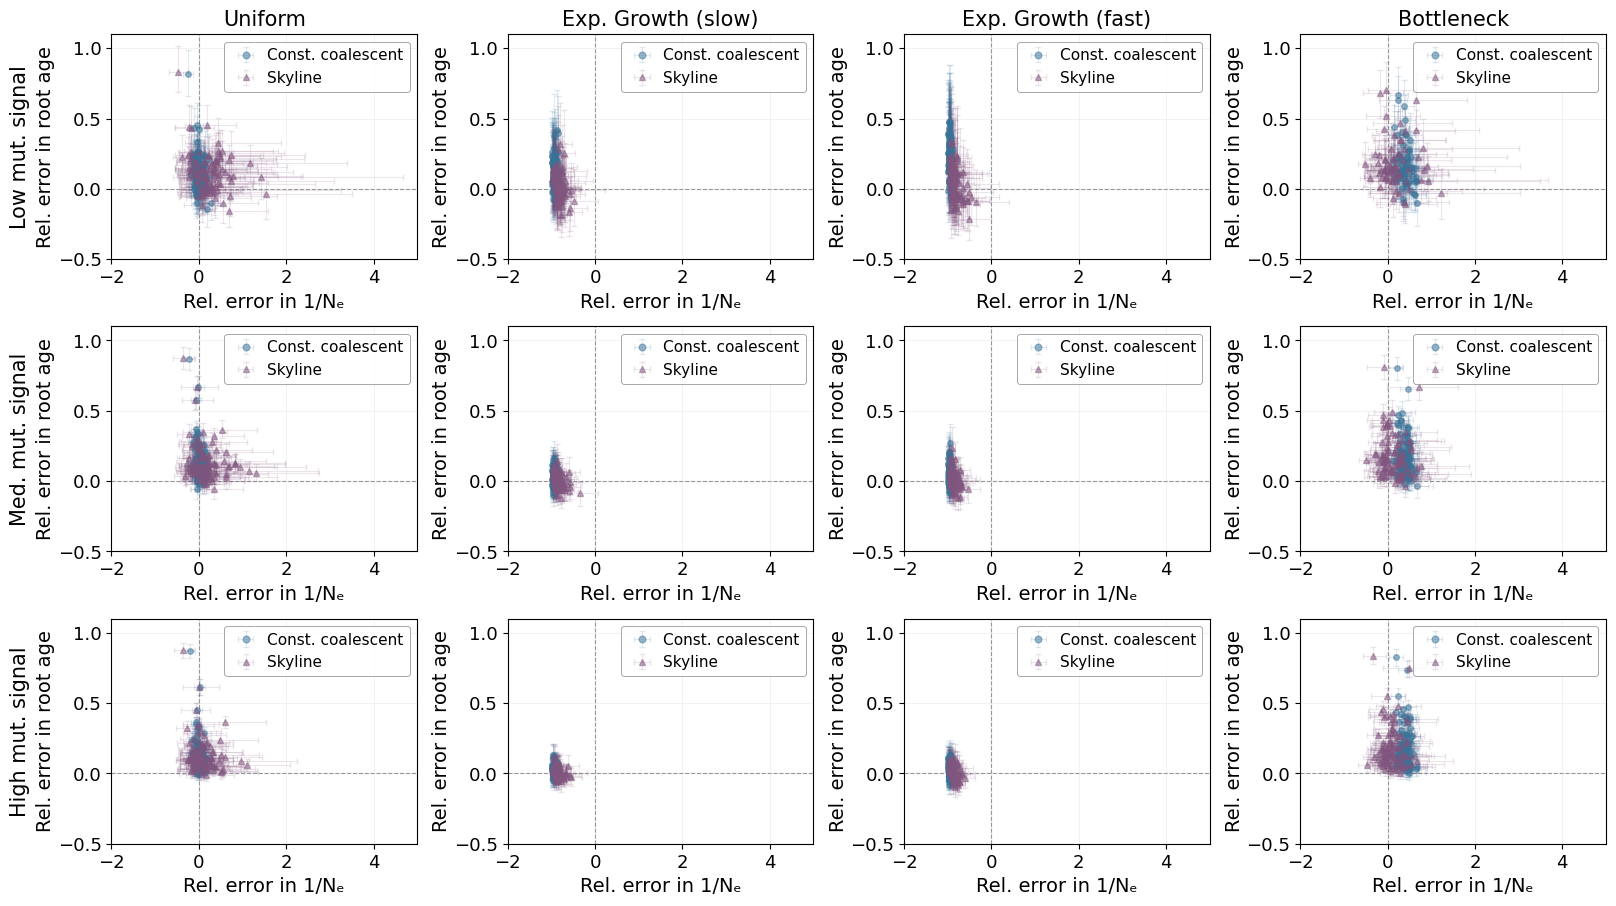

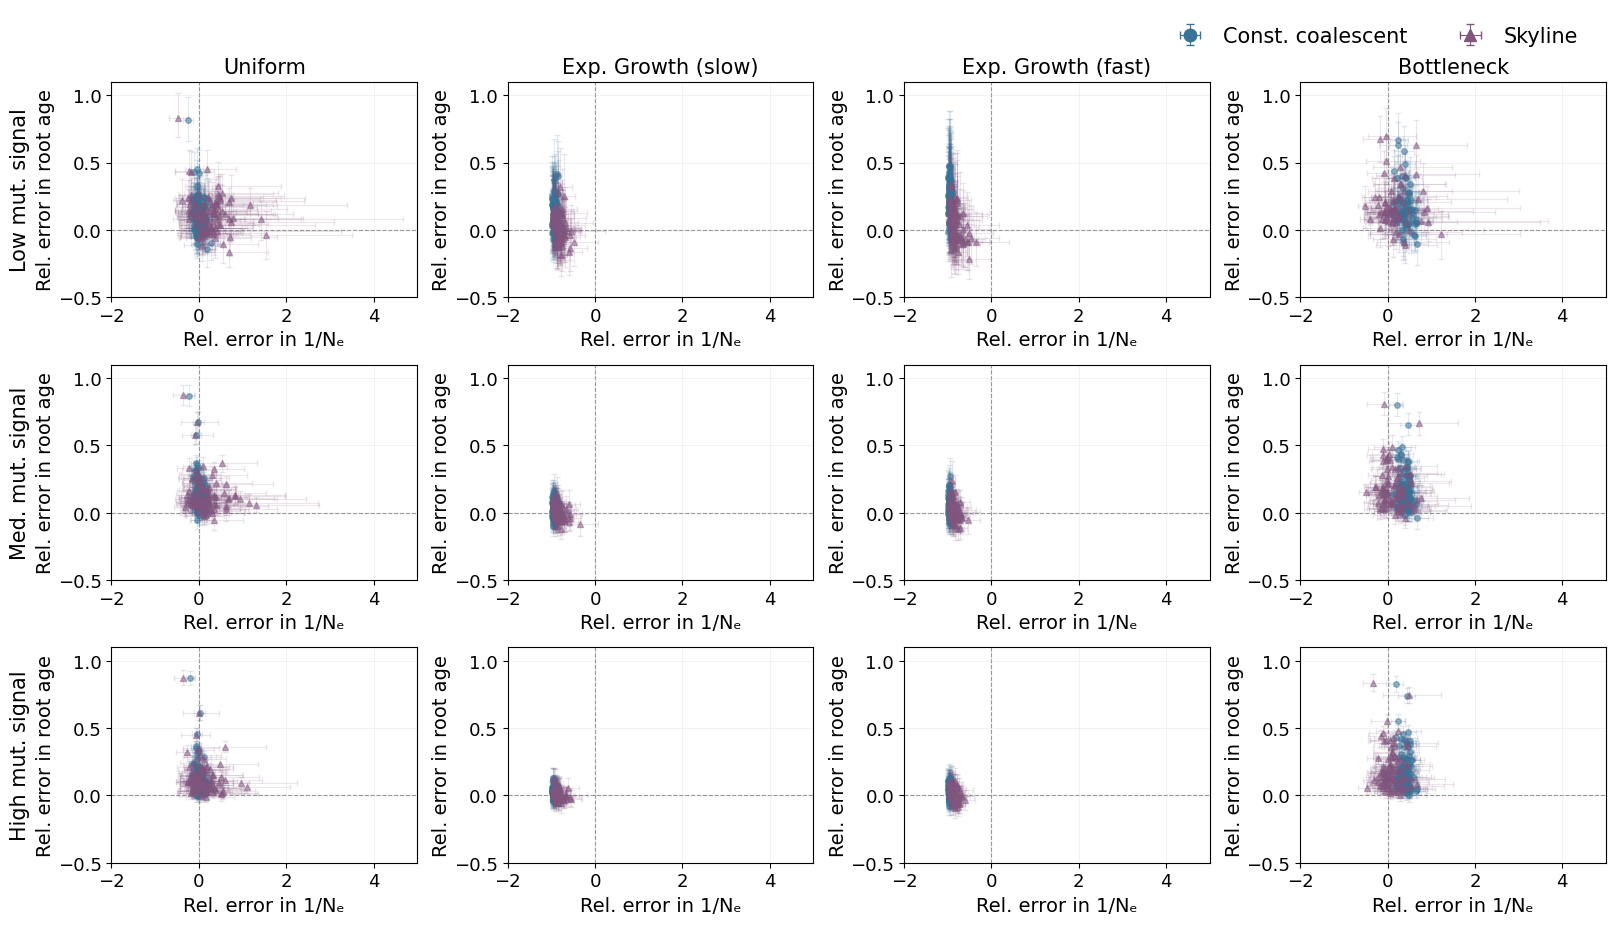

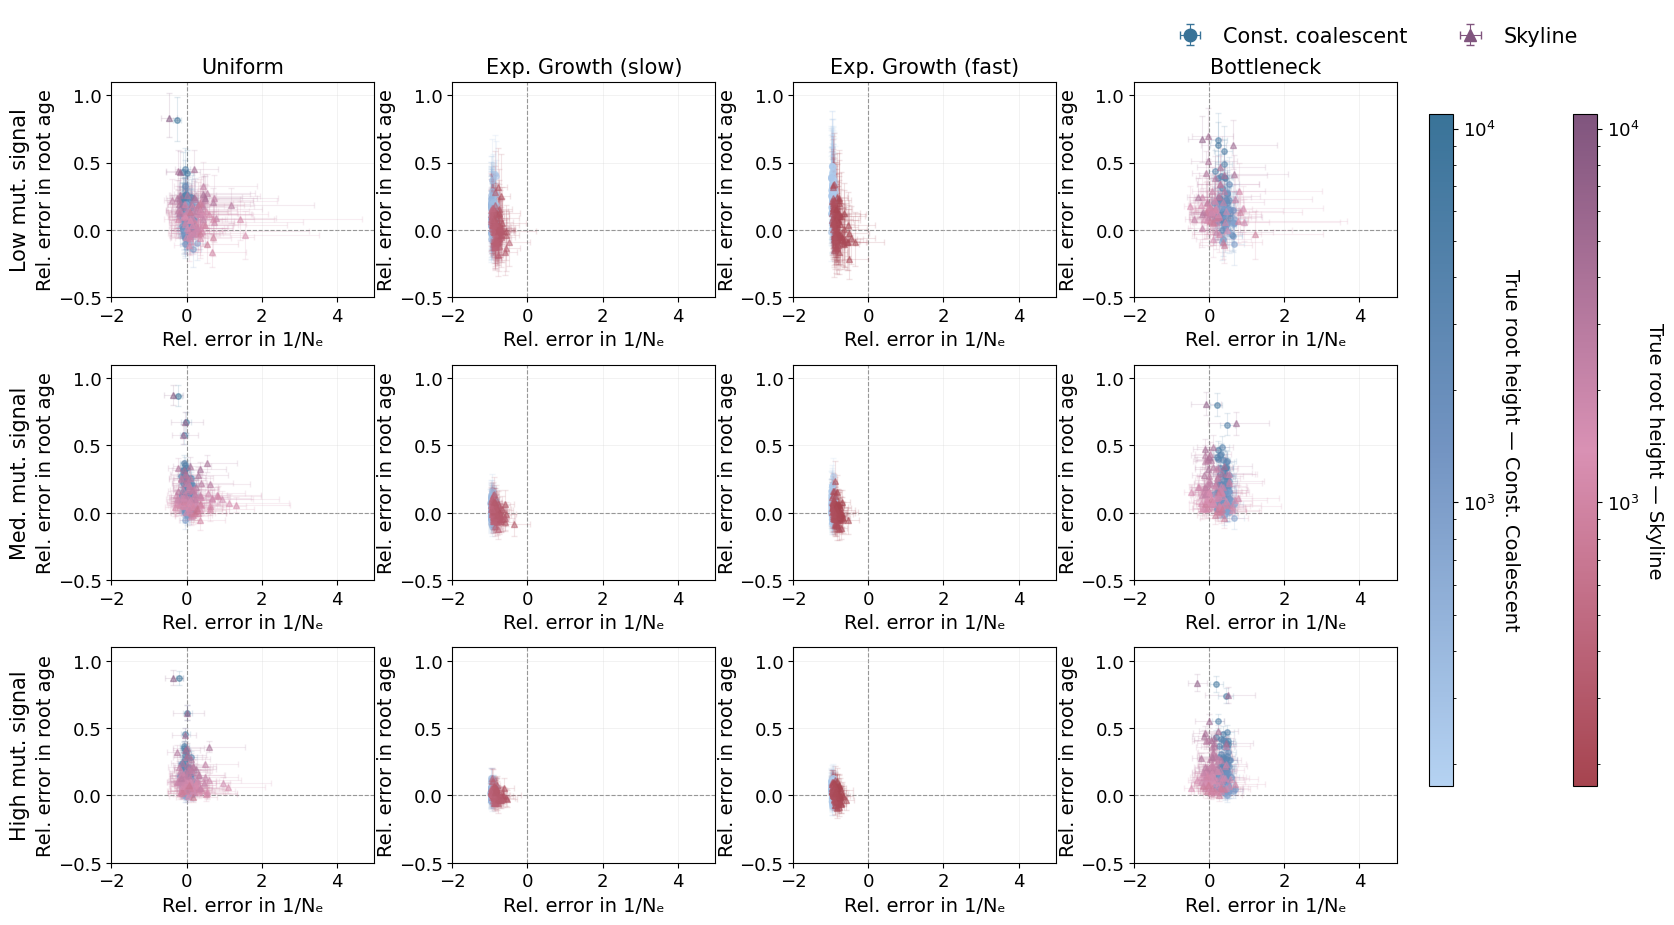

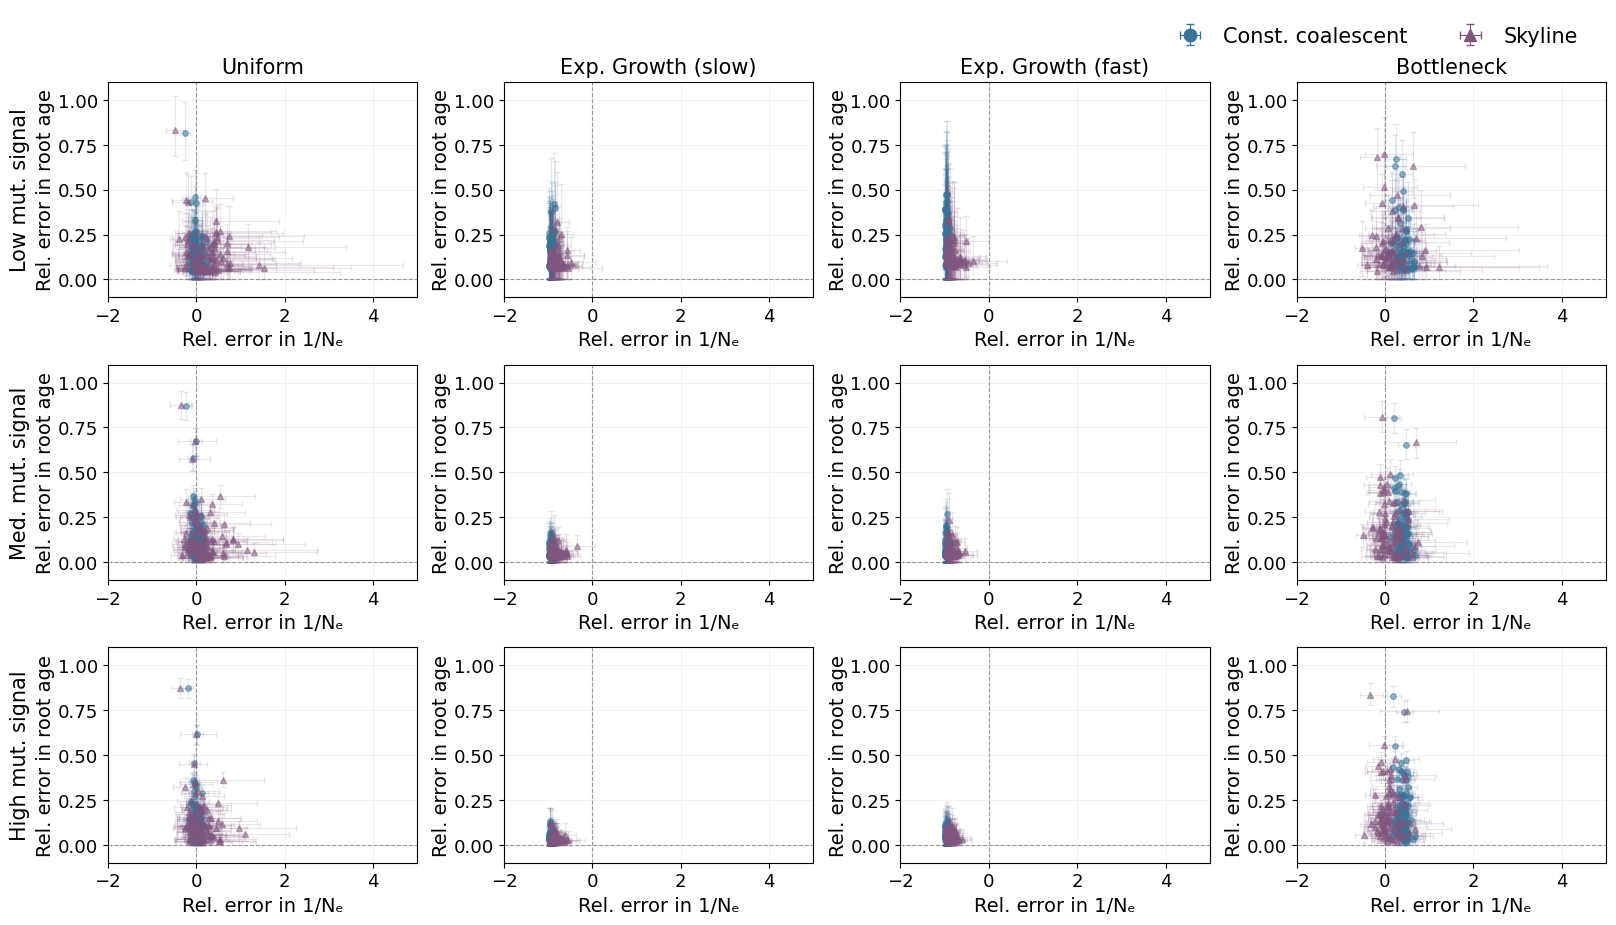

In [8]:
# linearconstant

plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.5,1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_linearconstant_all_legendin.pdf", legend_inside = True)
plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.5, 1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_linearconstant_all_legendout.pdf", legend_inside = False)
plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.5, 1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_linearconstant_all_legendout_timecoloring.pdf", legend_inside = False,
                                color_by_time=True, time_col = "height_sim", log_colorbar=True)

plot_height_vs_popsize_error(root_height_df_wide, sampling="linearconstant", x_col="rate_rel_error_median", y_col="height_abs_rel_error_median", alpha = 0.5, s = 20, y_range = (-0.1, 1.1), x_range = (-2,5), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/abs_rootheight_rate_error_linearconstant_all_legendout.pdf", legend_inside = False)

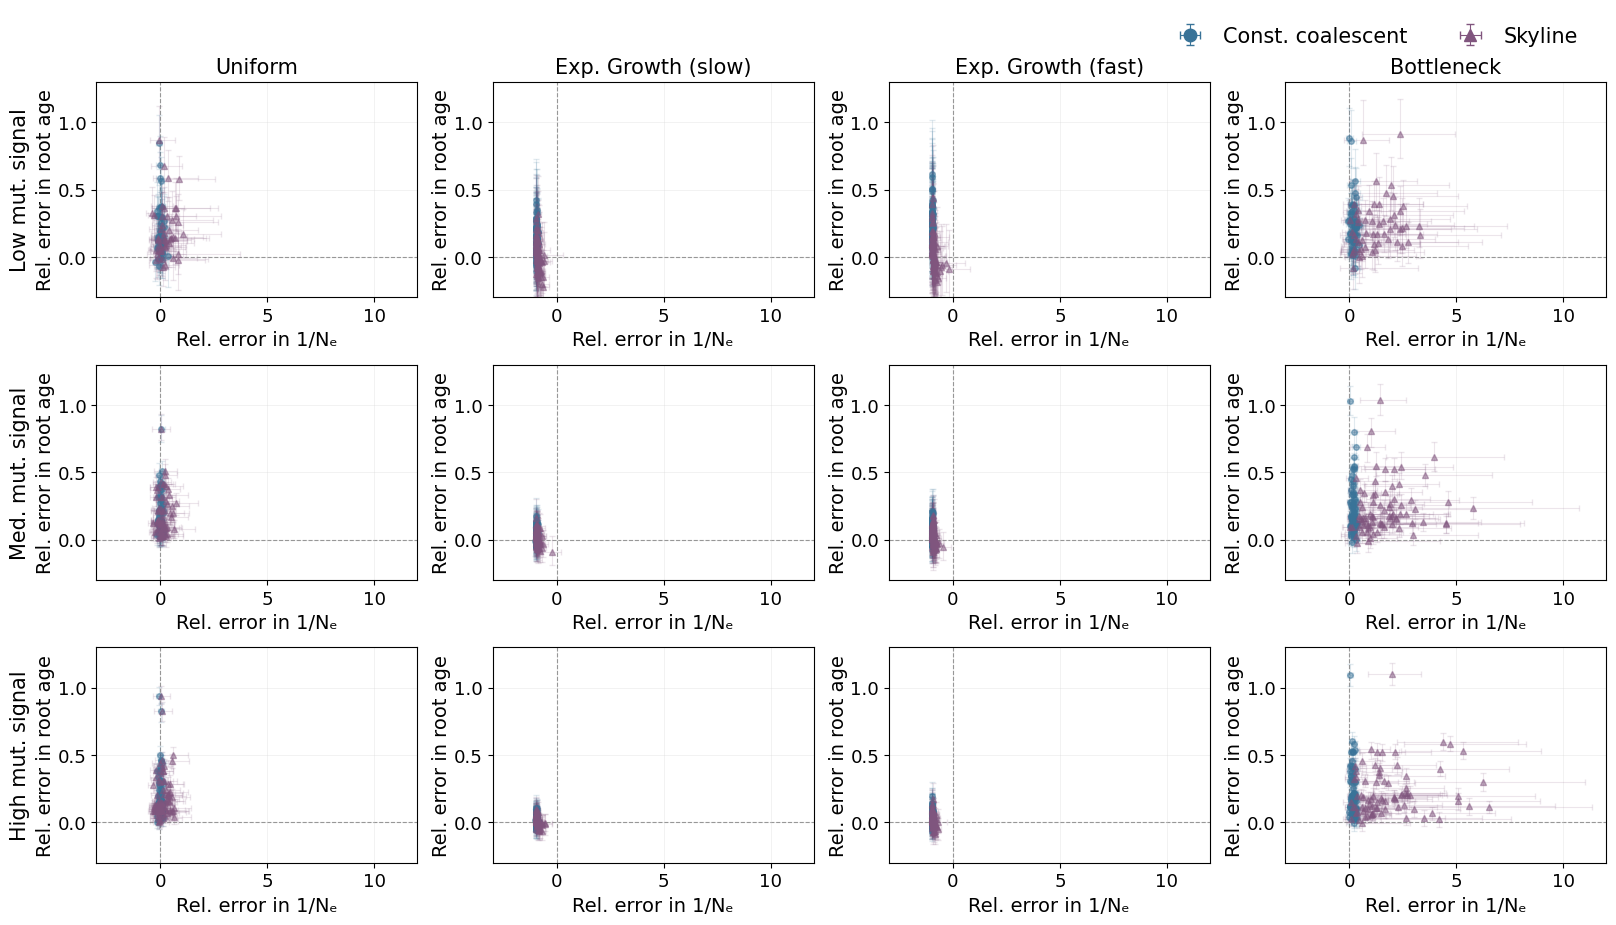

In [9]:
# indepedent homochronous
plot_height_vs_popsize_error(root_height_df_wide, sampling="independenthomochronous", x_col="rate_rel_error_median", y_col="height_rel_error_median", alpha = 0.5, s = 20, x_range = (-3,12), y_range = (-0.3,1.3), pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'], x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "", save_path="../figures/root_height/rootheight_rate_error_independenthomochronous_all_legendout.pdf", legend_inside = False)

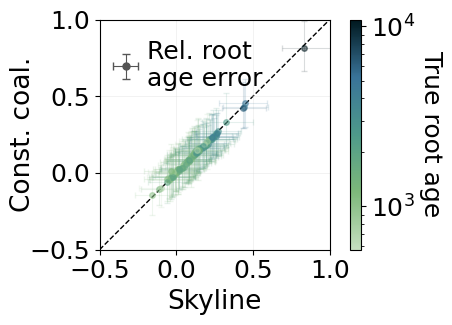

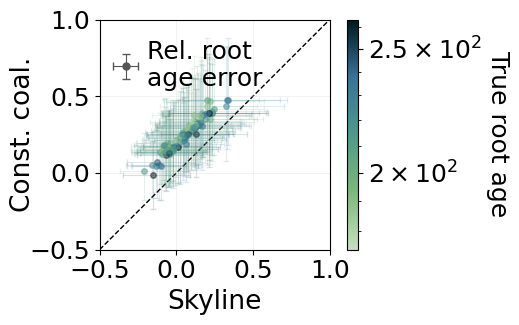

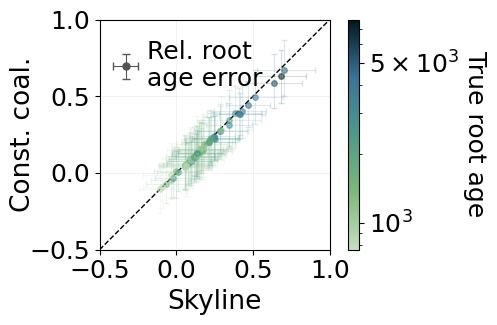

In [3]:
plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'age error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1), figsize = (6, 3.5),
                                   title = "", label_fontsize=19, tick_fontsize=18, legend_fontsize=18, cbar_tick_fontsize=18,
                                   pop_models = ['uniform'], mutsigs = ['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored_uniform.pdf")

plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'age error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1), figsize = (6, 3.5),
                                   title = "", label_fontsize=19, tick_fontsize=18, legend_fontsize=18, cbar_tick_fontsize=18,
                                   pop_models = ['expgrowthfast'], mutsigs = ['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored_expgrowthfast.pdf")

plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'age error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1), figsize = (6, 3.5),
                                   title = "", label_fontsize=19, tick_fontsize=18, legend_fontsize=18, cbar_tick_fontsize=18,
                                   pop_models = ['bottleneck'], mutsigs = ['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored_bottleneck.pdf")

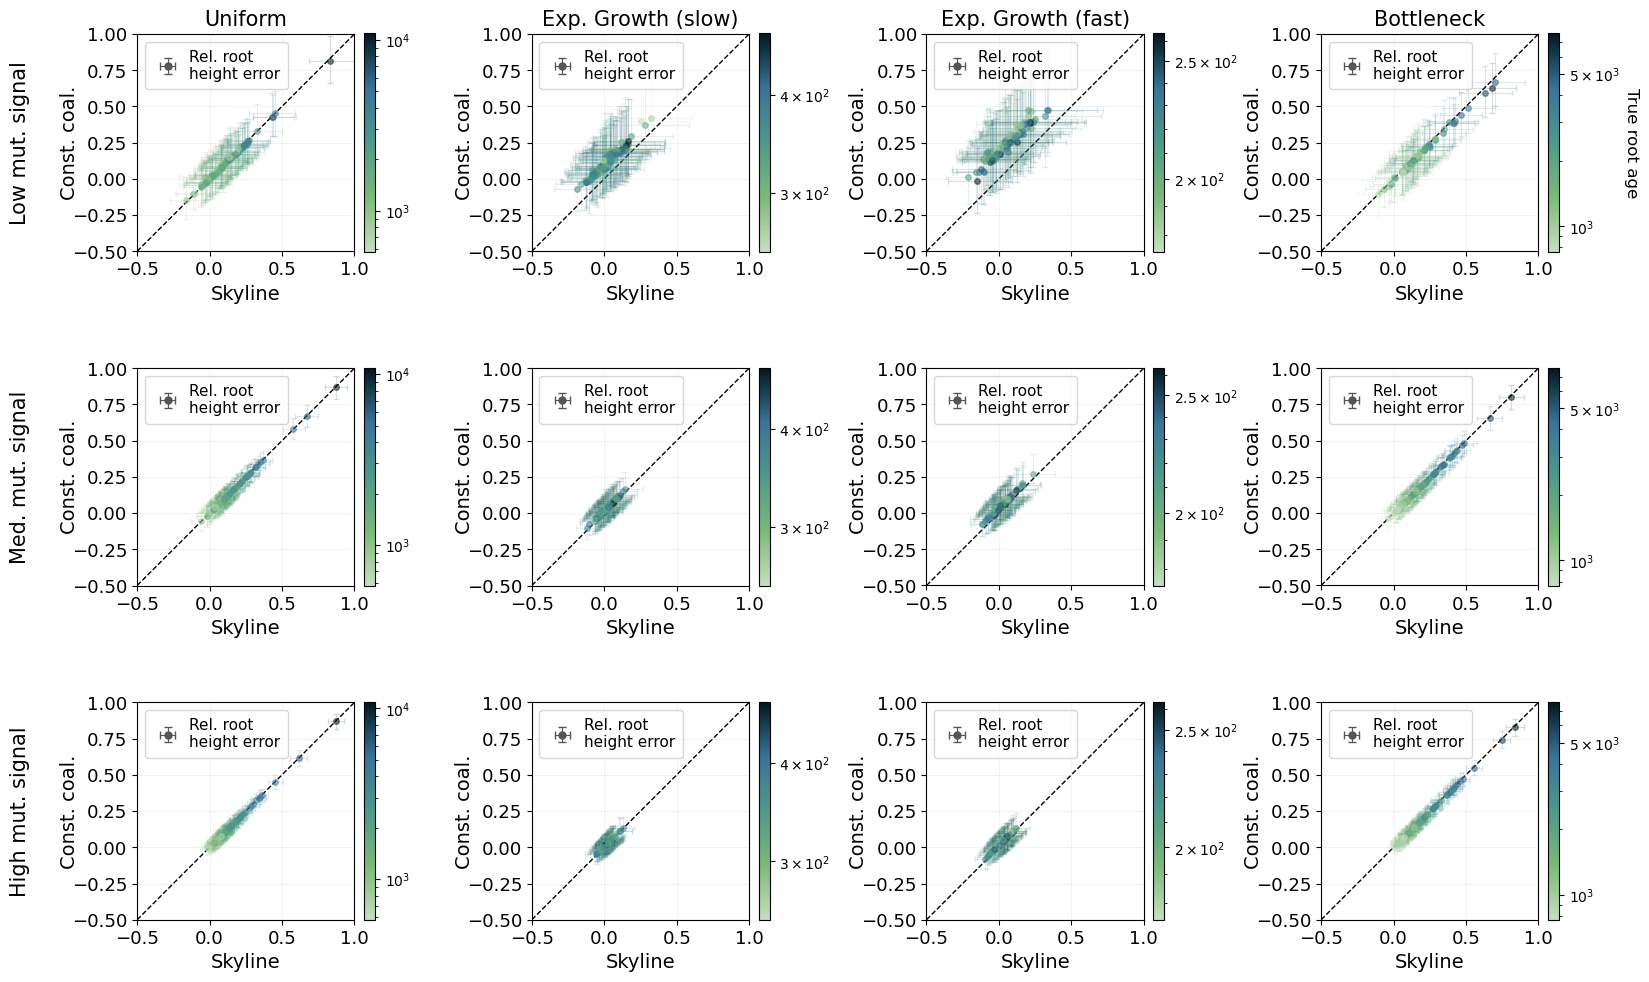

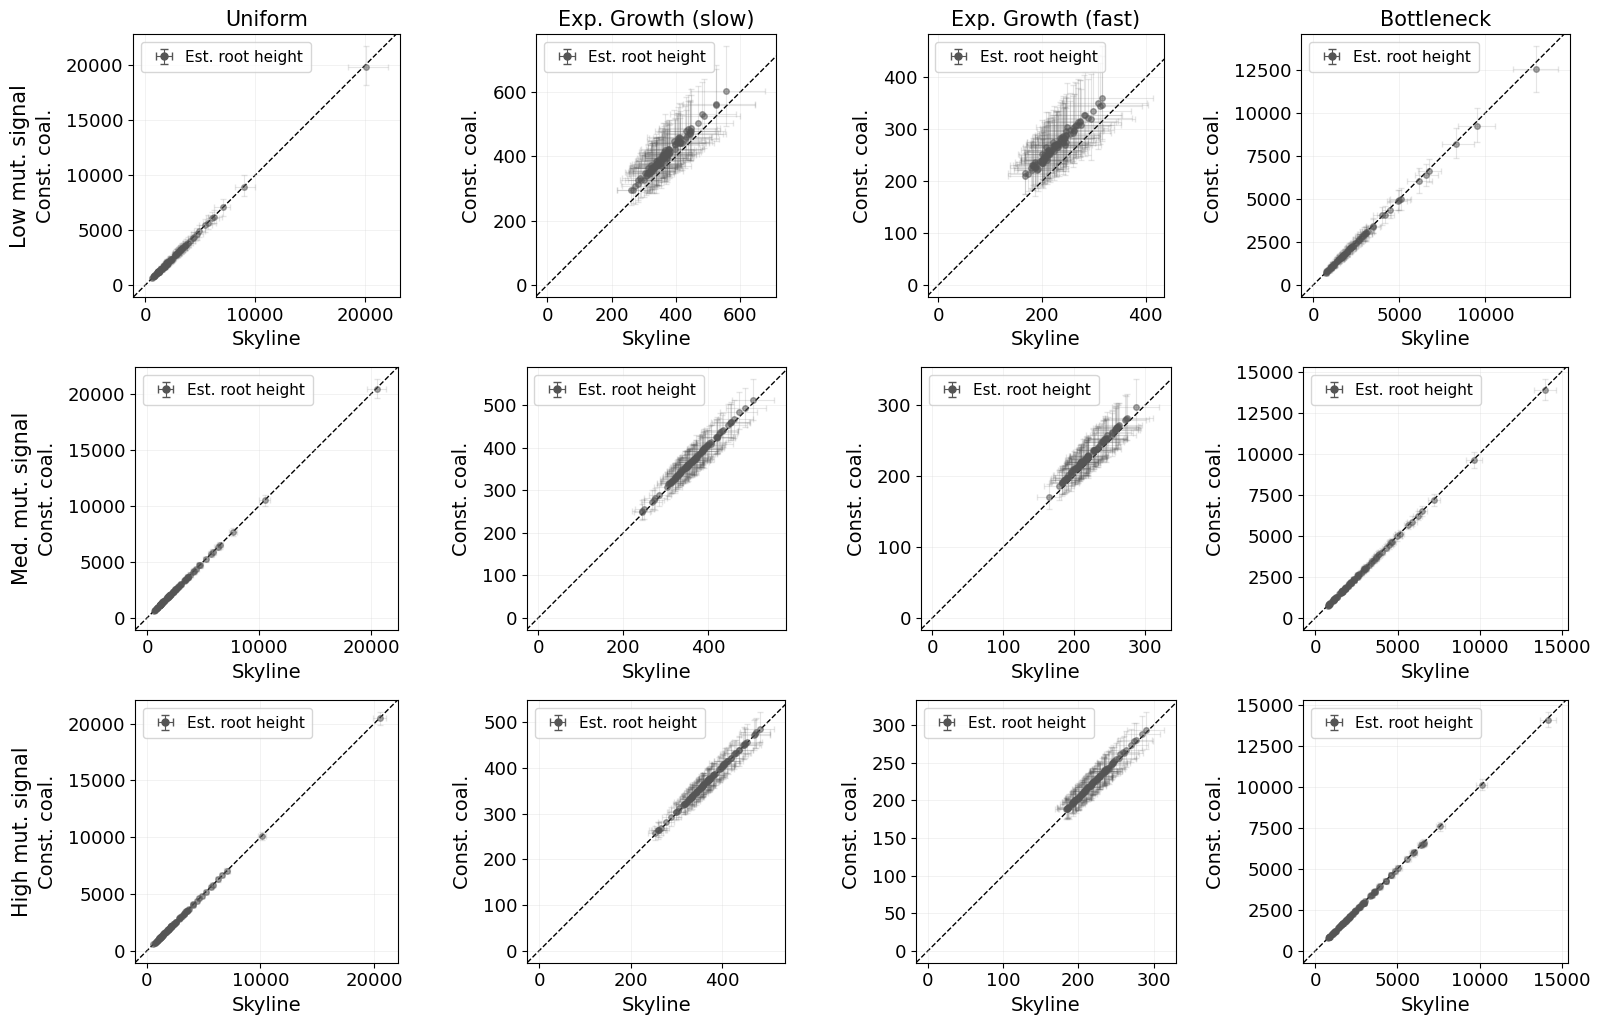

In [5]:
plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_rel_error_median", error_label = 'Rel. root \n' \
                                   'height error',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = (-0.5, 1), y_range = (-0.5,1),
                                   title = "",
                                   color_by_time = True, time_col = 'height_sim', log_colorbar = True,
                                   save_path="../figures/root_height/skyline_constcoal_comparison_relrootheighterror_colored.pdf")

plot_constcoal_vs_skyline_error(root_height_df_wide, sampling="linearconstant",
                                   error_col="height_est", error_label = 'Est. root height',
                                   x_label="Skyline", y_label="Const. coal.",
                                   x_range = None, y_range = None,
                                   title = "",
                                   save_path="../figures/root_height/skyline_constcoal_comparison_estimatedrootheight.pdf")

## Box plot that summarizes all root heights

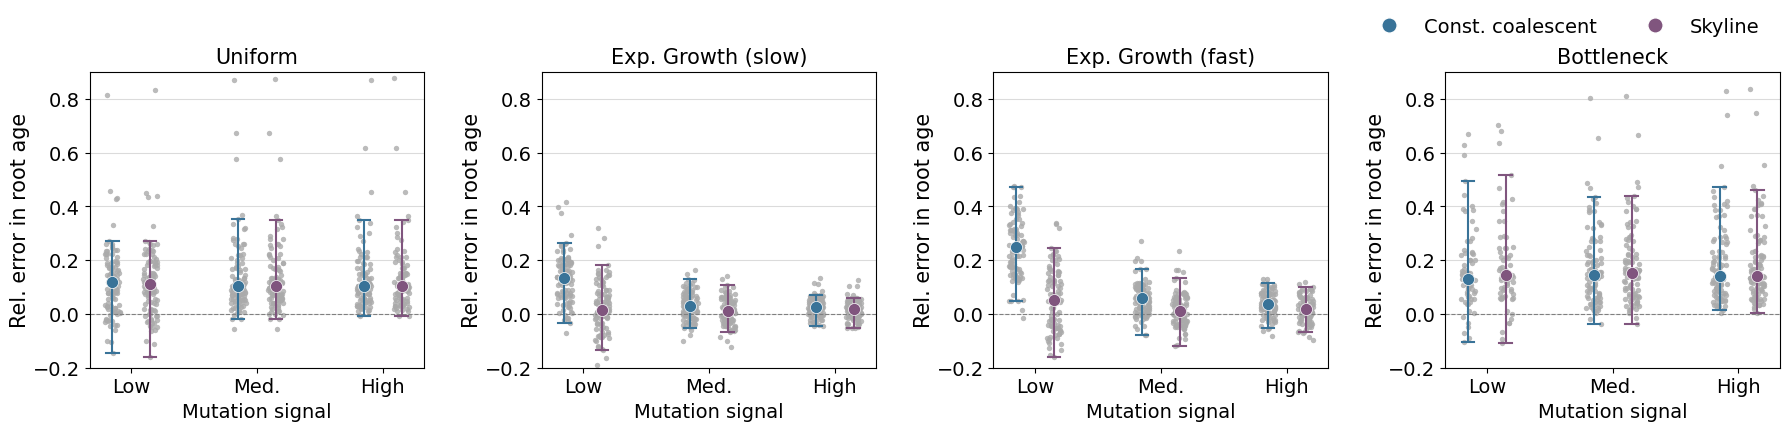

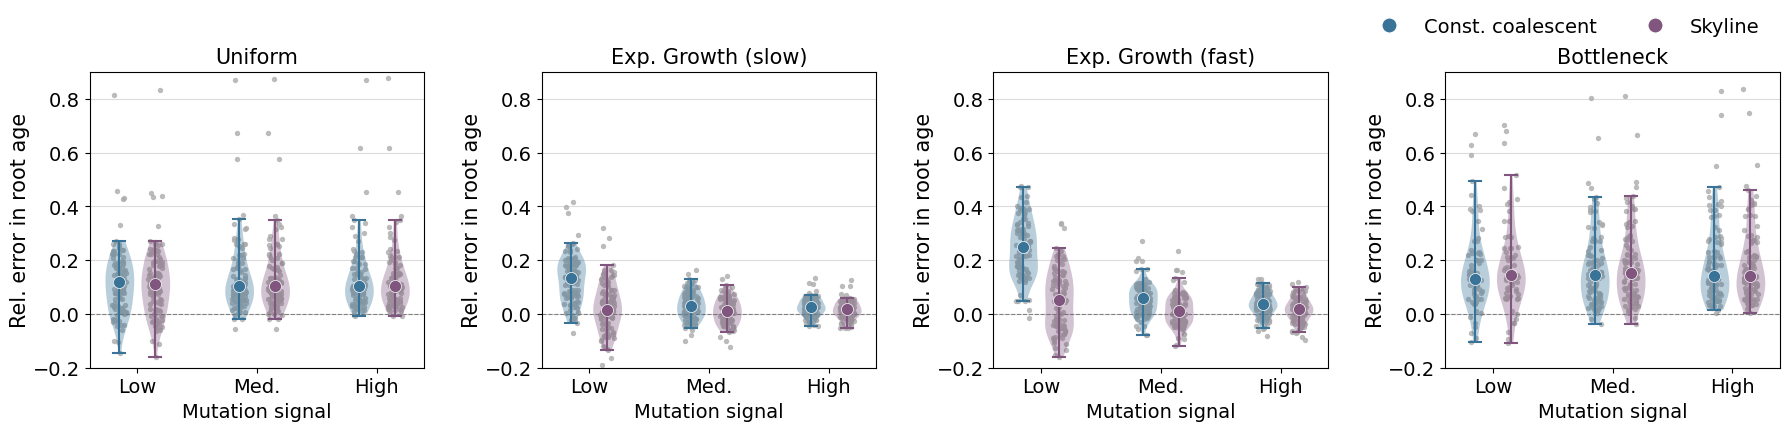

In [3]:
plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_rel_error_median", y_label="Rel. error in root age", y_range=(-0.2, 0.9),
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_root_error_scatter_linearconstant.pdf")

plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_rel_error_median", y_label="Rel. error in root age", y_range=(-0.2, 0.9),
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_root_error_scatter_linearconstant_violin.pdf", violin = True)

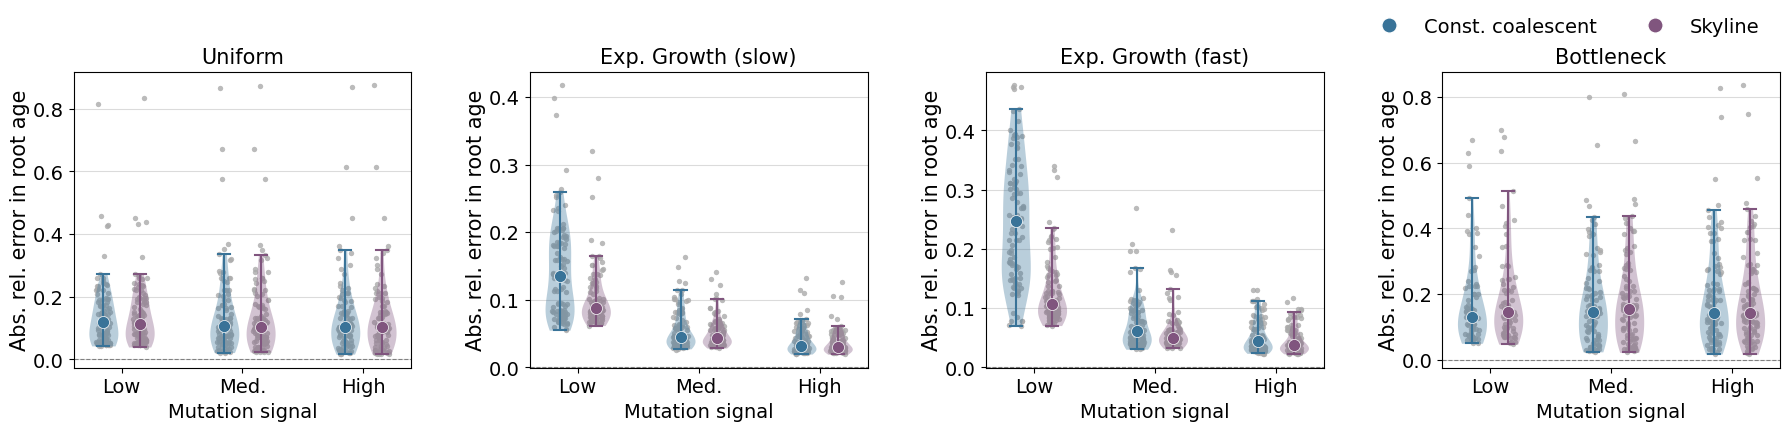

In [4]:
plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="Abs. rel. error in root age", y_range=None,
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin.pdf", violin = True)

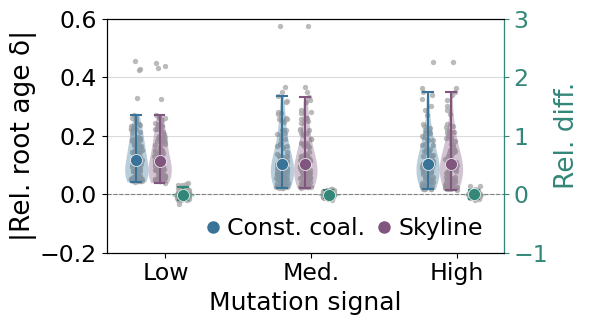

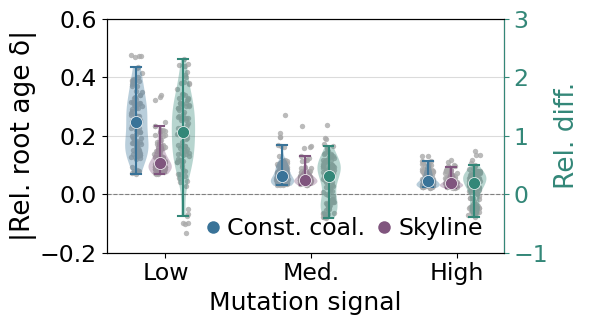

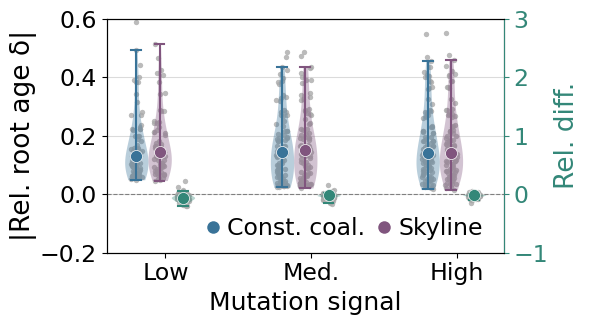

In [4]:
plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="|Rel. root age δ|", y_range = (-0.2, 0.6),
                        pop_models=['uniform'], figsize=(6,3.5), legend_inside=True,
                        show_diff=True, diff_mode="relative", diff_y_range = (-1,3),
                        show_pop_model_labels = False, label_fontsize=18, tick_fontsize=17, legend_fontsize=17,
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin_uniform.pdf", violin = True)

plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="|Rel. root age δ|", y_range = (-0.2, 0.6),
                        pop_models=['expgrowthfast'], figsize=(6,3.5), legend_inside=True,
                        show_diff=True, diff_mode="relative", diff_y_range = (-1, 3),
                        show_pop_model_labels = False, label_fontsize=18, tick_fontsize=17, legend_fontsize=17,
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin_expgrowthfast.pdf", violin = True)

plot_error_by_mutsig(root_height_df_wide, sampling = 'linearconstant',
                        y_col="height_abs_rel_error_median", y_label="|Rel. root age δ|", y_range = (-0.2, 0.6),
                        pop_models=['bottleneck'], figsize=(6,3.5), legend_inside=True,
                        show_diff=True, diff_mode="relative", diff_y_range = (-1, 3),
                        show_pop_model_labels = False, label_fontsize=18, tick_fontsize=17, legend_fontsize=17,
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_linearconstant_violin_bottleneck.pdf", violin = True)

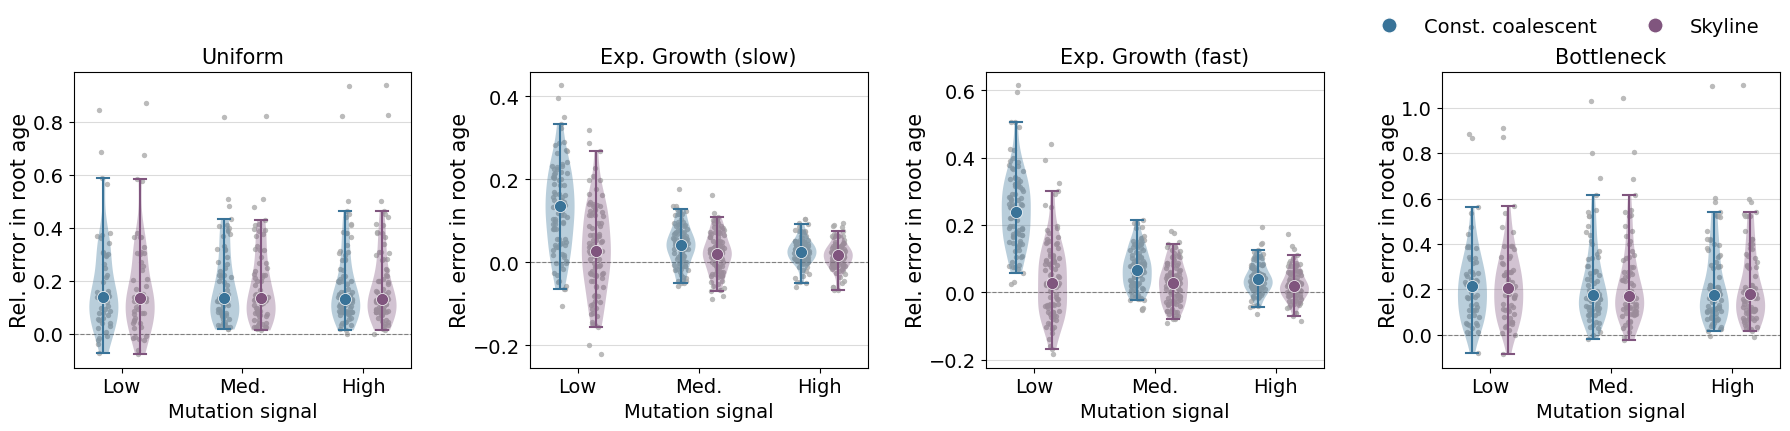

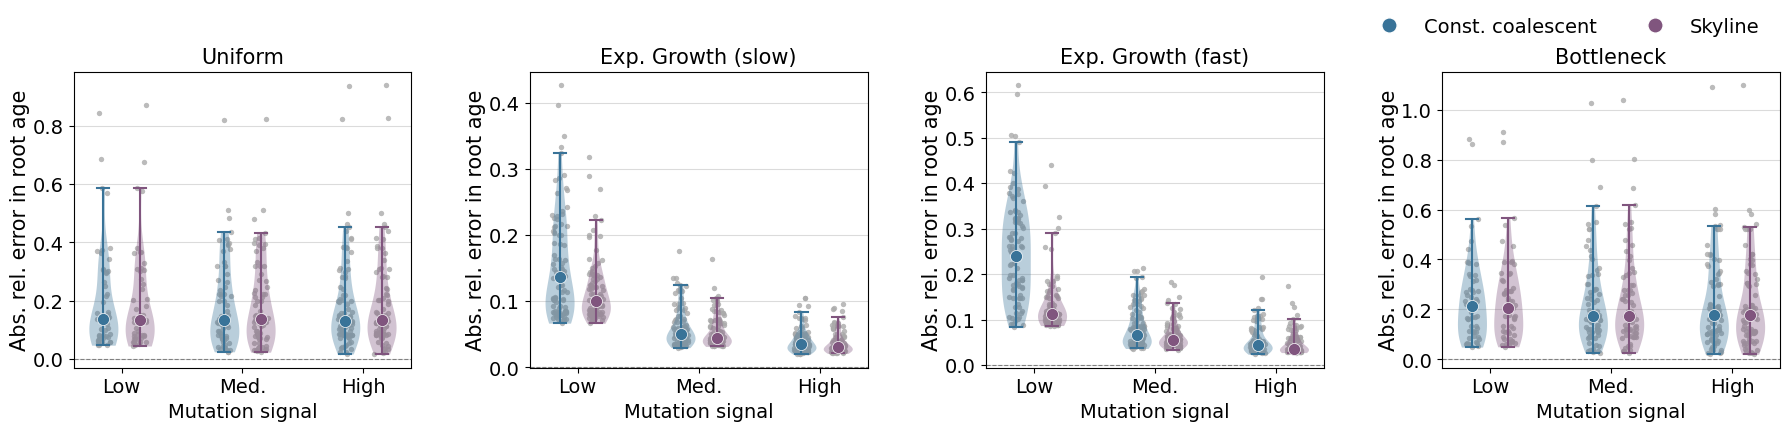

In [5]:
# independent homochronous
plot_error_by_mutsig(root_height_df_wide, sampling = 'independenthomochronous',
                        y_col="height_rel_error_median", y_label="Rel. error in root age", y_range=None,
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_root_error_scatter_independenthomochronous_violin.pdf", violin = True)

plot_error_by_mutsig(root_height_df_wide, sampling = 'independenthomochronous',
                        y_col="height_abs_rel_error_median", y_label="Abs. rel. error in root age", y_range=None,
                        pop_models=['uniform', 'expgrowthslow', 'expgrowthfast', 'bottleneck'],
                        title="", save_path="../figures/root_height/summary_abs_root_error_scatter_independenthomochronous_violin.pdf", violin = True)